# MINI PROJETO SCTEC

# Análise Exploratória de Dados de uma Base de Varejo

1) Visão geral:

A base de dados contém registros reais de compras realizadas num varejo. Há dados relacionados a datas, clientes, produtos, categorias e valores.

- **Objetivo:** Realizar uma AED a fim de preparar a base para análises mais aprofundadas ou alimentar dashboards.
- **Objetivos específicos:** Limpeza; estatística básica; tratamento de valores nulos;

2) Tecnologias utilizadas:

- **Python 3.13.15**
- **Pandas & Numpy**
- **Matplotlib & seaborn**
- **VSCode**

3) Dicionário de dados:

- DATA: Data da compra;
- CO_ID: Identificação do número de compra (número da nota fiscal);
- CL_ID: Identificação do cliente (número do cliente);
- CL_GENERO: Sexo biológico informado pelo cliente;
- CL_EC: Estado civil do cliente: 
    1 = Casado ou união estával; 
    2 = Divorciado; 
    3 = Separado; 
    4 = Solteiro; 
    5 = Viúvo.
- CL_FHL: Número de filhos do cliente; 
- CL_SEG: Segmentação econômica do cliente (classe A, B ou C); 
- PR_ID: Código do produto (SKU) adquirido; 
- PR_CAT: Categoria do produto adquirido; 
- PR_NOME: Nome do produto adquirido. 

## Imports

In [1]:
# Importação de bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento da base de dados

In [3]:
# Carregamento da base de dados através do read_csv
# Renomeando como df_varejo
df_varejo = pd.read_csv("Base_Varejo.csv", sep=';')

## AED

- Análise exploratória de dados iniciais

**Objetivos:** Verificar cada coluna do dataset, procurando dados nulos, duplicatas e/ou erros de formato (ex.: data) para limpeza e padronização.

In [4]:
# Visualização das 7 primeiras linhas da base de dados
df_varejo.head(7)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN
5,01/02/2019,1000,534,M,4,1,C,187,HIGIENE,HASTES FLEXIVEIS,NaN,NaN,NaN,NaN
6,01/02/2019,1000,534,M,4,1,C,163,ALIMENTOS,MORTADELA,NaN,NaN,NaN,NaN


In [5]:
# Verificando as informações do DF
df_varejo.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


**OBSERVAÇÕES:** Percebe-se que há 4 colunas (Unnamed: 10 - 13) que estão vazias.

**Ações:** 
- Cópia do DF
- Exclusão dessas colunas vazias

In [6]:
# Cópia do dataframe para análises
df_varejo_copia = df_varejo.copy()

In [7]:
# Visualização das informações do df copiado
df_varejo_copia.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


In [8]:
# Exclusão dascolunas de índices 10 a 13
df_varejo_copia = df_varejo_copia.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])

# Visualização das informações
df_varejo_copia.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   DATA       830000 non-null  str  
 1   CO_ID      830000 non-null  int64
 2   CL_ID      830000 non-null  int64
 3   CL_GENERO  830000 non-null  str  
 4   CL_EC      830000 non-null  int64
 5   CL_FHL     830000 non-null  int64
 6   CL_SEG     830000 non-null  str  
 7   PR_ID      830000 non-null  int64
 8   PR_CAT     830000 non-null  str  
 9   PR_NOME    830000 non-null  str  
dtypes: int64(5), str(5)
memory usage: 63.3 MB


**Primeiros resultados**

Após cópia e limpeza inicial do df, resultou-se no 'df_varejo_copia' que contém as seguintes informações iniciais:

- 10 colunas
- 5 colunas do tipo *int64*
- 5 colunas do tipo *str*
- 830 mil dados não nulos

Obs.: 4 colunas foram excluídas do dataset inicial por estarem zeradas e sem nomes, não sendo importantes ou relevantes para as análises futuras.

### AED - DATA

**Ações realizadas:**

- Conversão do tipo str para datetime64[us] - somente para cálculos do pandas e numpy
- Uso do errors='coerce' para tratar dados fora do formato de data, como algum texto (ex.: 'hello, world!') no lugar de números no formato dd/mm/aaaa
- Cálculo das datas min e max e período de cobertura total, para verificar se havia discrepância entre os dados (datas muito antigas ou futuras)
- Feature engineering das colunas ANO, MÊS, DIA_DA_SEMANA e FIM_DE_SEMANA
- A coluna FIM_DE_SEMANA é do tipo (dtype) bool, onde True é o fim de semana (sábado ou domingo) e False é dia útil.
- Frequência de compras nos dias da semana

In [9]:
# Conversão do tipo de dados 'str' para 'datetime64[ns]'
# Conversão para o padrão brasileiro dd/mm/aaaa
df_varejo_copia['DATA'] = pd.to_datetime(df_varejo_copia['DATA'], format='%d/%m/%Y', errors='coerce') # errors='coerce' transformará strings corrompidas em NaT

# Verificação de erro na conversão de datas (NaT)
datas_invalidas = df_varejo_copia['DATA'].isna().sum()
print(f'Total de datas corrompidas (NaT): {datas_invalidas}')

Total de datas corrompidas (NaT): 0


In [10]:
# Informação da coluna DATA
df_varejo_copia['DATA'].info()

<class 'pandas.Series'>
RangeIndex: 830000 entries, 0 to 829999
Series name: DATA
Non-Null Count   Dtype         
--------------   -----         
830000 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 6.3 MB


In [11]:
# Amostra de dados da coluna DATA
df_varejo_copia['DATA'].sample(7)

5206     2019-09-01
417162   2020-12-30
411698   2020-12-20
135664   2019-06-09
611102   2021-10-13
410178   2020-12-14
135559   2019-06-09
Name: DATA, dtype: datetime64[us]

In [12]:
# Verificando min e max das datas (cobertura temporal)
data_min = df_varejo_copia['DATA'].min()
data_max = df_varejo_copia['DATA'].max()
periodo_total = data_max - data_min

print(f'Data inicial: {data_min.strftime('%d/%m/%Y')}')
print(f'Data final: {data_max.strftime('%d/%m/%Y')}')
print(f'Janela temporal: {periodo_total.days} dias')

Data inicial: 04/01/2019
Data final: 08/12/2022
Janela temporal: 1434 dias


In [13]:
# Extraindo novos componentes das datas: ANO, MÊS, DIA_DA_SEMANA e FIM_DE_SEMANA
# ANO
df_varejo_copia['ANO'] = df_varejo_copia['DATA'].dt.year

# MÊS
df_varejo_copia['MES'] = df_varejo_copia['DATA'].dt.month

# DIA_DA_SEMANA
df_varejo_copia['DIA_SEMANA'] = df_varejo_copia['DATA'].dt.day_name(locale='pt_BR')

# FIM_DE_SEMANA
df_varejo_copia['FIM_DE_SEMANA'] = df_varejo_copia['DATA'].dt.day_of_week.isin([5,6]) # 0 = segunda, 6 = domingo

In [14]:
# Verificando as novas colunas do DF
df_varejo_copia.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   DATA           830000 non-null  datetime64[us]
 1   CO_ID          830000 non-null  int64         
 2   CL_ID          830000 non-null  int64         
 3   CL_GENERO      830000 non-null  str           
 4   CL_EC          830000 non-null  int64         
 5   CL_FHL         830000 non-null  int64         
 6   CL_SEG         830000 non-null  str           
 7   PR_ID          830000 non-null  int64         
 8   PR_CAT         830000 non-null  str           
 9   PR_NOME        830000 non-null  str           
 10  ANO            830000 non-null  int32         
 11  MES            830000 non-null  int32         
 12  DIA_SEMANA     830000 non-null  str           
 13  FIM_DE_SEMANA  830000 non-null  bool          
dtypes: bool(1), datetime64[us](1), int32(2), int64(5), str(5)
memor

In [ ]:
# Frequência de compras por dia da semana
df_varejo_copia['DIA_SEMANA'].value_counts()

DIA_SEMANA
Quarta-feira     153560
Sexta-feira      132633
Domingo          130503
Segunda-feira    111786
Quinta-feira     105474
Terça-feira      101656
Sábado            94388
Name: count, dtype: int64

### AED - CO_ID

**Ações realizadas:**
- Verificação de dados nulos, zeros e negativos
- Análise do total de itens, compras distintas e média de itens por compra
- Basket Size
- Consistência temporal

In [20]:
# Verificação de valores nulos (NaN/None)
print(f'Valores nulos (Nan/None): {df_varejo_copia['CO_ID'].isna().sum()}')

# Checagem de dados inconsistentes (ID's zero ou negativos)
print(f'IDs zerados: {(df_varejo_copia['CO_ID'] == 0).sum()}')
print(f'IDs negativos: {(df_varejo_copia['CO_ID'] < 0).sum()}')

Valores nulos (Nan/None): 0
IDs zerados: 0
IDs negativos: 0


In [21]:
# Comparação da quantidade de itens vendidos com a quantidade real de compras realizadas
total_linhas = len(df_varejo_copia)
pedidos_unicos = df_varejo_copia['CO_ID'].nunique()
media_itens_pedido = total_linhas/pedidos_unicos

print(f'Total de registros (itens): {total_linhas}')
print(f'Total de compras distintas: {pedidos_unicos}')
print(f'Média de itens por compra: {media_itens_pedido:.2f}')

Total de registros (itens): 830000
Total de compras distintas: 18471
Média de itens por compra: 44.94


**Basket Size**

Analisa o tamanho da cesta de cada cliente, permitindo entender um pouco do perfil do cliente (se faz compras rápidas, com poucos itens ou o contrário) e identificar outliers (compras com 600 itens, por exemplo)

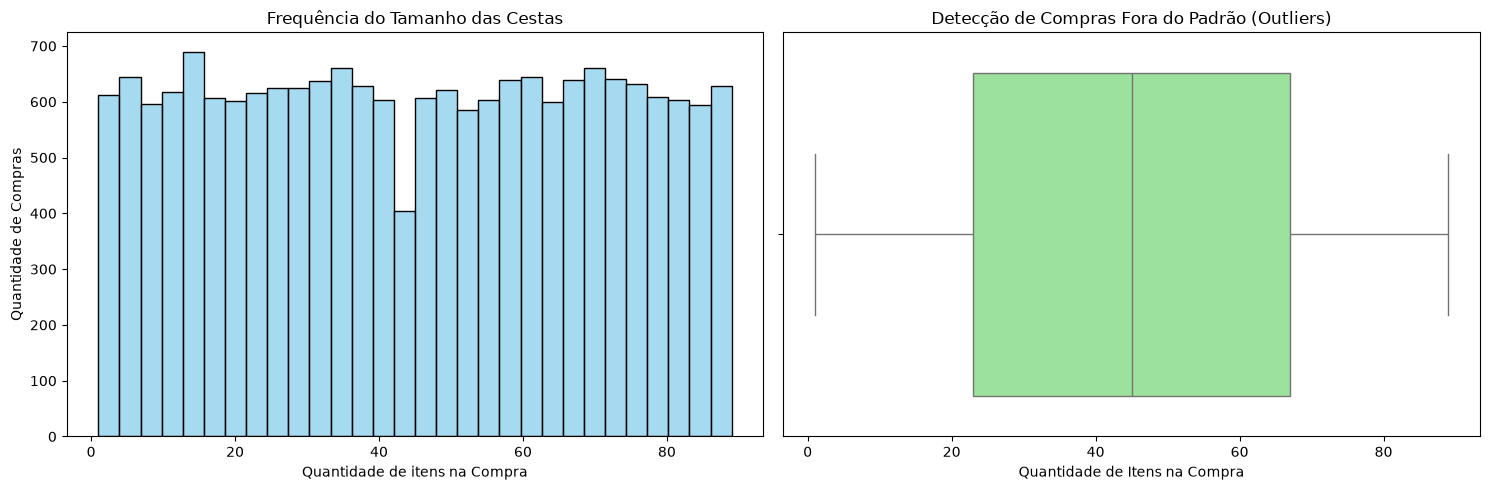

Cestas mais frequentes:
count
1    207
2    191
3    214
4    209
5    194
Name: count, dtype: int64


In [22]:
# Tamanho da cesta
tamanho_cesta = df_varejo_copia['CO_ID'].value_counts()

# Configuração da área do gráfico para exibição lado a lado
fig, axes = plt.subplots(1,2, figsize=(15,5))

# Gráfico 1: Histograma (distribução dos dados)
sns.histplot(tamanho_cesta, bins=30, kde=False, color='skyblue', ax=axes[0])
axes[0].set_title('Frequência do Tamanho das Cestas')
axes[0].set_xlabel('Quantidade de itens na Compra')
axes[0].set_ylabel('Quantidade de Compras')

# Gráfico 2: boxplot (Outliers)
sns.boxplot(x=tamanho_cesta, color='lightgreen', ax=axes[1])
axes[1].set_title('Detecção de Compras Fora do Padrão (Outliers)')
axes[1].set_xlabel('Quantidade de Itens na Compra')

# Ajuste do layout e exibição
plt.tight_layout()
plt.show()

# Exibição das cestas mais comuns
print('Cestas mais frequentes:')
print(tamanho_cesta.value_counts().sort_index().head(5))

**Consistência temporal**

Verificação da regra de negócio relacionada a data de compra e o identificador de compra.
Sabemos que o mesmo CO_ID não deve aparecer em datas diferentes, então vamos verificar:

In [23]:
# Verificação se o mesmo CO_ID tem diferentes atribuições de datas
datas_por_compra = df_varejo_copia.groupby('CO_ID')['DATA'].nunique()
inconsistencias_data = datas_por_compra[datas_por_compra > 1]

print(f'Compras com mais de uma data registrada: {len(inconsistencias_data)}')

Compras com mais de uma data registrada: 0


### AED - PR_CAT

**Ações relaizadas:**

- Verificação de dados inconsistentes
- Padronização de texto (upper)
- Listagem das categorias

In [24]:
# Valores nulos
print(f'Valores nulos (NaN): {df_varejo_copia['PR_CAT'].isna().sum()}')

Valores nulos (NaN): 0


In [25]:
# Textos vazios ou preenchidos com espaço
vazios = df_varejo_copia['PR_CAT'].str.strip().eq('').sum()
print(f'Textos vazios ou somente com espaço: {vazios}')

Textos vazios ou somente com espaço: 0


In [26]:
# Visualizando dados sortidos da coluna PR_CAT
df_varejo_copia['PR_CAT'].sample(7)

574151    ALIMENTOS
622296    ALIMENTOS
631277      LIMPEZA
259002    ALIMENTOS
637482      HIGIENE
26771       LIMPEZA
400361    ALIMENTOS
Name: PR_CAT, dtype: str

In [27]:
# Colocando em maiúsculo e removendo espaços inicial e final
df_varejo_copia['PR_CAT'] = df_varejo_copia['PR_CAT'].astype(str).str.strip().str.upper()

# Listando os valores únicos para procurar erros de digitação ou mesma categoria digitada diferente (papel/papéis)
print(sorted(df_varejo_copia['PR_CAT'].unique()))


['#N/D', 'ACESSORIOS', 'ALIMENTOS', 'BEBIDAS', 'HIGIENE', 'LIMPEZA', 'PET']


**Observação:**

foi encontrada uma categoria sem definição (#N/D)

Os próximos passos servirão para analisar a soma total desses dados e seu valor relativo em relação ao total de dados, assim tomaremos a decisão de excluí-los ou não (tratamento)

In [28]:
# Contagem do total de percentual de #N/D
qtd_nd = (df_varejo_copia['PR_CAT'] == '#N/D').sum()
perc_nd = (qtd_nd/len(df_varejo_copia))*100

print(f'Linhas com #N/D: {qtd_nd} ({perc_nd:.2f}% da base)')

Linhas com #N/D: 3650 (0.44% da base)


**Observação:**

Foram encontrados 3650 dados com o formato '#N/D', representando 0,44% da base de dados.

**Objetivo:**

O objetivo agora é verificar se esses dados são aleatórios ou representam um determinado produto ainda não cadastrado. No primeiro caso, os dados serão excluídos, porém no segundo caso, a exclusão  faria com que a database ficasse com um viés, então o ideal seria o tratamento desses dados.

In [29]:
# Criando uma coluna temporária para analisar os dados #N/D
df_varejo_copia['ERRO_CAT'] = df_varejo_copia['PR_CAT'] == '#N/D'  # O valor #N/D receberá o valor True

In [30]:
# Teste de sazonalidade do erro
erros_por_mes = df_varejo_copia[df_varejo_copia['ERRO_CAT']]['DATA'].dt.to_period('M').value_counts().sort_index()
print("Quantidade de #N/D por mês:")
print(erros_por_mes)

Quantidade de #N/D por mês:
DATA
2019-01     27
2019-02     88
2019-03     50
2019-04     91
2019-05    122
2019-06    103
2019-07     61
2019-08     91
2019-09     81
2019-10     43
2019-11     26
2019-12     98
2020-01     90
2020-02     99
2020-03     75
2020-04     76
2020-05     69
2020-06     59
2020-07     45
2020-08     87
2020-09     95
2020-10    115
2020-11     67
2020-12     57
2021-01    114
2021-02     82
2021-03     78
2021-04     76
2021-05     69
2021-06     90
2021-07    110
2021-08     84
2021-09    124
2021-10    143
2021-11     46
2021-12     71
2022-01    145
2022-02     76
2022-03     59
2022-04     70
2022-05    104
2022-06     55
2022-07     80
2022-08     51
2022-09      7
2022-10     11
2022-11     24
2022-12     66
Freq: M, Name: count, dtype: int64


In [33]:
# Teste de perfil de compra
cesta_com_erro = df_varejo_copia[df_varejo_copia['ERRO_CAT']]['CO_ID'].value_counts().mean()
cesta_sem_erro = df_varejo_copia[~df_varejo_copia['ERRO_CAT']]['CO_ID'].value_counts().mean()

print(f'Média de itens por compra COM erro: {cesta_com_erro:.2f}')
print(f'Média de itens por compra SEM erro: {cesta_sem_erro:.2f}')

Média de itens por compra COM erro: 1.13
Média de itens por compra SEM erro: 44.74


**RESULTADO DESSAS ANÁLISES:**

Apesar dos dados #N/D estarem relativamente bem distribuídos nos meses analisados, ele não está aleatoriamente distribuído quando calculada a média de itens por compra COM e SEM erro.

O resultado dessa última análise demonstra que há um padrão (viés) descoberto, pois os erros ocorrem basicamente em cestas com poucos ou 1 item. Ou seja, não há um MCAR - Missing Completely At Ramdom. Dessa forma, não iremos apagar os dados, mas sim renomeá-los para 'DESCONHECIDO'.